# Notebook 01: Exploración de Datos (EDA)

**Objetivo**: Realizar un análisis exploratorio del dataset de emociones musicales de Spotify.

**Contenido**:
1. Carga del dataset desde CSV
2. Análisis de dimensiones, tipos de datos y uso de memoria
3. Visualización de distribución de emociones (target)
4. Análisis de valores nulos
5. Correlaciones entre features numéricas

---

## 1. Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración de visualización
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Carga del Dataset

Cargamos el dataset de Spotify con 500K canciones desde el archivo CSV.

In [22]:
# Cargar dataset
df = pd.read_csv('../data/spotify_dataset.csv')

print(f"✓ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✓ Dataset cargado: 551,443 filas × 39 columnas


## 3. Análisis de Dimensiones y Tipos de Datos

In [23]:
# Dimensiones
print("=" * 60)
print("DIMENSIONES DEL DATASET")
print("=" * 60)
print(f"Filas (canciones): {df.shape[0]:,}")
print(f"Columnas (features): {df.shape[1]}")
print()

DIMENSIONES DEL DATASET
Filas (canciones): 551,443
Columnas (features): 39



In [24]:
# Tipos de datos
print("=" * 60)
print("TIPOS DE DATOS")
print("=" * 60)
print(df.dtypes)
print()

# Conteo por tipo
print("Resumen por tipo:")
print(df.dtypes.value_counts())
print()

TIPOS DE DATOS
Artist(s)                          object
song                               object
text                               object
Length                             object
emotion                            object
Genre                              object
Album                              object
Release Date                       object
Key                                object
Tempo                               int64
Loudness (db)                      object
Time signature                     object
Explicit                           object
Popularity                          int64
Energy                              int64
Danceability                        int64
Positiveness                        int64
Speechiness                         int64
Liveness                            int64
Acousticness                        int64
Instrumentalness                    int64
Good for Party                      int64
Good for Work/Study                 int64
Good for Relaxation

In [25]:
# Uso de memoria
print("=" * 60)
print("USO DE MEMORIA")
print("=" * 60)
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Uso total de memoria: {memory_mb:.2f} MB")
print()

# Uso por columna (top 10)
memory_per_col = df.memory_usage(deep=True).sort_values(ascending=False).head(10) / (1024 ** 2)
print("Top 10 columnas con mayor uso de memoria:")
for col, mem in memory_per_col.items():
    if col != 'Index':
        print(f"  {col}: {mem:.2f} MB")

USO DE MEMORIA
Uso total de memoria: 1950.00 MB

Top 10 columnas con mayor uso de memoria:
  text: 1249.80 MB
  Album: 39.83 MB
  Release Date: 38.28 MB
  Similar Artist 1: 38.17 MB
  Similar Artist 2: 38.17 MB
  Artist(s): 38.16 MB
  Similar Artist 3: 38.16 MB
  song: 37.59 MB
  Similar Song 1: 37.59 MB
  Similar Song 3: 37.56 MB


## 4. Primeras Filas del Dataset

In [26]:
# Mostrar primeras 10 filas
print("Primeras 10 filas del dataset:")
print()
df.head(10)

Primeras 10 filas del dataset:



,Artist(s),song,text,Length,emotion,Genre,Album,Release Date,Key,Tempo,...,Good for Morning Routine,Similar Artist 1,Similar Song 1,Similarity Score 1,Similar Artist 2,Similar Song 2,Similarity Score 2,Similar Artist 3,Similar Song 3,Similarity Score 3
0,!!!,Even When the Waters Cold,Friends told her she was better off at the bot...,03:47,sadness,hip hop,Thr!!!er,29th April 2013,D min,105,...,0,Corey Smith,If I Could Do It Again,0.986061,Toby Keith,Drinks After Work,0.983719,Space,Neighbourhood,0.983236
1,!!!,One Girl / One Boy,"Well I heard it, playing soft From a drunken b...",04:03,sadness,hip hop,Thr!!!er,29th April 2013,A# min,117,...,0,Hiroyuki Sawano,BRE@TH//LESS,0.995409,When In Rome,Heaven Knows,0.990905,Justice Crew,Everybody,0.984483
2,!!!,Pardon My Freedom,"Oh my god, did I just say that out loud? Shoul...",05:51,joy,hip hop,Louden Up Now,8th June 2004,A Maj,121,...,0,Ricky Dillard,More Abundantly Medley Live,0.993176,Juliet,Avalon,0.965147,The Jacksons,Lovely One,0.956752
3,!!!,Ooo,[Verse 1] Remember when I called you on the te...,03:44,joy,hip hop,As If,16th October 2015,A min,122,...,0,Eric Clapton,Man Overboard,0.992749,Roxette,Don't Believe In Accidents,0.991494,Tiwa Savage,My Darlin,0.990381
4,!!!,Freedom 15,[Verse 1] Calling me like I got something to s...,06:00,joy,hip hop,As If,16th October 2015,F min,123,...,0,Cibo Matto,Lint Of Love,0.981610,Barrington Levy,Better Than Gold,0.981524,Freestyle,Its Automatic,0.981415
5,!!!,All U Writers,All you writers Get out your pens and write Al...,05:22,love,hip hop,All U Writers / Gonna Guetta Stomp,27th April 2015,B min,122,...,0,Wish & Fonda Rae,Touch Me All Night Long,0.980839,Gary Numan,War Songs,0.980527,Little Dragon,Forever,0.980209
6,!!!,Serbia Drums,[Verse 1] We've known working in obscurity and...,03:39,sadness,hip hop,Wallop,30th August 2019,E min,104,...,0,Talking Heads,Ruby Dear,0.980781,Hanson,Something Going Round,0.979205,"Hoodie Allen,Jared Evan",Same As Before,0.978977
7,!!!,Must Be the Moon,"One drink, two drinks, three drinks, four She ...",05:57,joy,hip hop,Myth Takes,5th March 2007,G Maj,120,...,0,"Crystal Waters,Steve ""Silk"" Hurley",Makin Happy,0.985045,Marvin Gaye,Sanctified Lady,0.974169,Ready For The World,Digital Display,0.973508
8,!!!,Slyd,"No, that's weird Slyd, slyd, slyd, you like t...",04:14,surprise,hip hop,Thr!!!er,29th April 2013,C Maj,120,...,0,"Moon Boots,Fiora",I Want Your Attention,0.992940,"Rhombus,Tiki Taane,MC Antsman,Imon Starr",Seen It All Beast Mix,0.991243,"Craig Reever,Easton",Special about You,0.989623
9,!!!,Hello? Is This Thing On?,Sometimes you don't say nothing 'cause you got...,07:33,sadness,hip hop,Louden Up Now,8th June 2004,G Maj,124,...,1,Midnight Star,Operator,0.985598,"Boris Dlugosch,Róisín Murphy,Ricky Mattioli",Never Enough,0.979075,YACHT,Miles Miles,0.978798


## 5. Estadísticas Descriptivas

Estadísticas de las columnas numéricas.

In [27]:
# Estadísticas de columnas numéricas
df.describe()

,Tempo,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness,Good for Party,...,Good for Relaxation/Meditation,Good for Exercise,Good for Running,Good for Yoga/Stretching,Good for Driving,Good for Social Gatherings,Good for Morning Routine,Similarity Score 1,Similarity Score 2,Similarity Score 3
count,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,...,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000
mean,120.513567,32.258106,62.661874,59.195460,47.738330,11.663980,19.655658,25.748436,7.152255,0.061809,...,0.030772,0.187334,0.053842,0.021484,0.057797,0.012253,0.066215,0.984107,0.979013,0.975938
std,29.185533,18.033931,22.399159,17.511007,24.159671,12.342389,16.274817,29.343731,20.589200,0.240808,...,0.172700,0.390180,0.225707,0.144990,0.233360,0.110014,0.248658,0.013559,0.015438,0.016512
min,31.000000,0.000000,0.000000,6.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002656,0.002647,0.002647
25%,97.000000,20.000000,48.000000,47.000000,28.000000,4.000000,10.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.977433,0.971582,0.967926
50%,120.000000,30.000000,65.000000,60.000000,47.000000,6.000000,13.000000,12.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.985926,0.980971,0.978078
75%,140.000000,43.000000,80.000000,72.000000,66.000000,15.000000,25.000000,43.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.993567,0.988592,0.986079
max,200.000000,100.000000,100.000000,99.000000,100.000000,97.000000,100.000000,100.000000,100.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 6. Análisis de la Variable Target: `emotion`

La columna `emotion` es nuestro target de clasificación.

In [28]:
# Valores únicos de emotion
print("=" * 60)
print("ANÁLISIS DE LA VARIABLE TARGET: emotion")
print("=" * 60)
print(f"Valores únicos: {df['emotion'].nunique()}")
print(f"Emociones: {sorted(df['emotion'].unique())}")
print()

ANÁLISIS DE LA VARIABLE TARGET: emotion
Valores únicos: 13
Emociones: ['Love', 'True', 'anger', 'angry', 'confusion', 'fear', 'interest', 'joy', 'love', 'pink', 'sadness', 'surprise', 'thirst']



In [29]:
# Distribución de emociones
emotion_counts = df['emotion'].value_counts()
print("Distribución de emociones:")
print(emotion_counts)
print()

# Porcentajes
emotion_pct = df['emotion'].value_counts(normalize=True) * 100
print("Porcentajes:")
for emotion, pct in emotion_pct.items():
    print(f"  {emotion}: {pct:.2f}%")

Distribución de emociones:
emotion
joy          209009
sadness      171078
anger        109678
fear          28097
love          27963
surprise       5592
True             17
Love              3
pink              2
angry             1
thirst            1
confusion         1
interest          1
Name: count, dtype: int64

Porcentajes:
  joy: 37.90%
  sadness: 31.02%
  anger: 19.89%
  fear: 5.10%
  love: 5.07%
  surprise: 1.01%
  True: 0.00%
  Love: 0.00%
  pink: 0.00%
  angry: 0.00%
  thirst: 0.00%
  confusion: 0.00%
  interest: 0.00%


## 7. Visualización de la Distribución de Emociones

Gráfico de barras para identificar desbalanceo de clases.

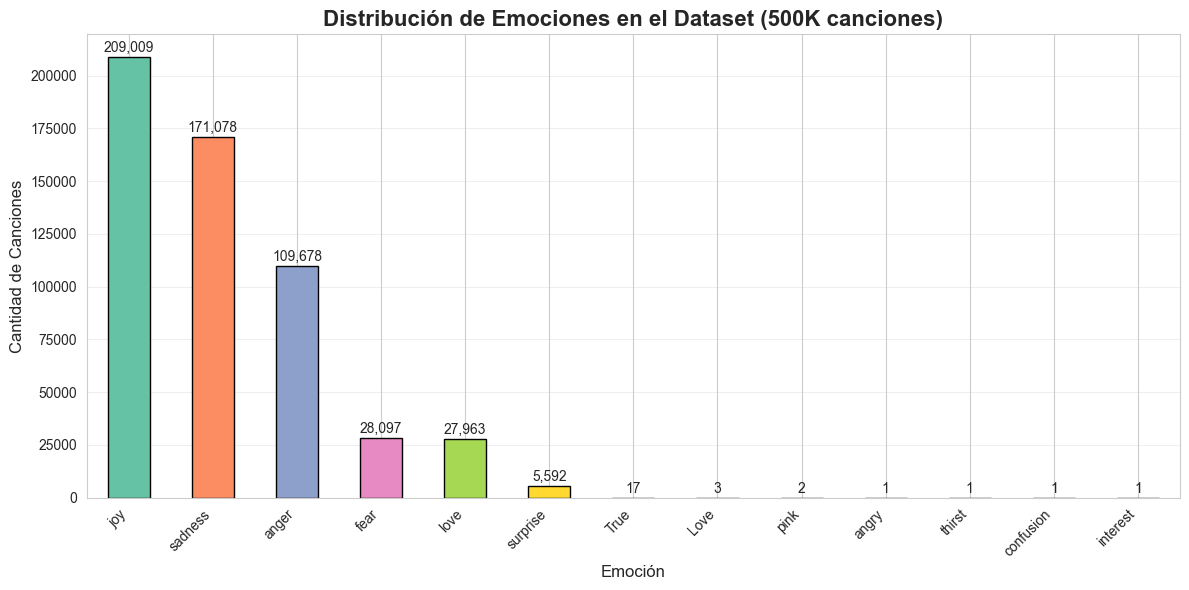

In [30]:
# Gráfico de barras de distribución de emociones
plt.figure(figsize=(12, 6))
emotion_counts = df['emotion'].value_counts()
colors = sns.color_palette('Set2', len(emotion_counts))
ax = emotion_counts.plot(kind='bar', color=colors, edgecolor='black')

# Etiquetas y título
plt.title('Distribución de Emociones en el Dataset (500K canciones)', fontsize=16, fontweight='bold')
plt.xlabel('Emoción', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Agregar valores sobre las barras
for i, v in enumerate(emotion_counts):
    ax.text(i, v + 1000, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

plt.show()

## 8. Análisis de Valores Nulos

Identificación de columnas con valores faltantes y su proporción.

In [31]:
# Contar valores nulos
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100

# Crear dataframe resumen
null_summary = pd.DataFrame({
    'Columna': df.columns,
    'Nulos': null_counts.values,
    'Porcentaje': null_pct.values
}).sort_values(by='Nulos', ascending=False)

# Filtrar solo las que tienen nulos
null_summary_filtered = null_summary[null_summary['Nulos'] > 0]

print("=" * 60)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 60)

if null_summary_filtered.empty:
    print("✅ No se encontraron valores nulos en ninguna columna.")
else:
    print(f"Columnas con valores nulos: {len(null_summary_filtered)}")
    print()
    for _, row in null_summary_filtered.iterrows():
        print(f"  {row['Columna']}: {row['Nulos']:,} ({row['Porcentaje']:.2f}%)")

print()
print(f"Total de valores nulos en el dataset: {null_counts.sum():,}")

ANÁLISIS DE VALORES NULOS
Columnas con valores nulos: 6

  Album: 52 (0.01%)
  Similar Song 2: 20 (0.00%)
  Similar Song 1: 19 (0.00%)
  song: 16 (0.00%)
  Time signature: 8 (0.00%)
  Similar Song 3: 4 (0.00%)

Total de valores nulos en el dataset: 119


## 9. Análisis de Correlaciones entre Features Numéricas

Matriz de correlación para identificar relaciones entre variables numéricas.

In [32]:
# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 60)
print("ANÁLISIS DE CORRELACIONES")
print("=" * 60)
print(f"Columnas numéricas detectadas: {len(numeric_cols)}")
print(f"Columnas: {', '.join(numeric_cols)}")
print()

# Calcular matriz de correlación
if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()
    
    # Identificar las 10 correlaciones más fuertes (excluyendo diagonal)
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                abs(corr_matrix.iloc[i, j])
            ))
    
    # Ordenar por correlación absoluta
    corr_pairs_sorted = sorted(corr_pairs, key=lambda x: x[2], reverse=True)[:10]
    
    print("Top 10 correlaciones más fuertes (valor absoluto):")
    for col1, col2, corr_val in corr_pairs_sorted:
        # Obtener signo original
        original_corr = corr_matrix.loc[col1, col2]
        print(f"  {col1} ↔ {col2}: {original_corr:.3f}")
else:
    print("⚠️  Solo hay una columna numérica. No se puede calcular correlación.")
    corr_matrix = None

ANÁLISIS DE CORRELACIONES
Columnas numéricas detectadas: 21
Columnas: Tempo, Popularity, Energy, Danceability, Positiveness, Speechiness, Liveness, Acousticness, Instrumentalness, Good for Party, Good for Work/Study, Good for Relaxation/Meditation, Good for Exercise, Good for Running, Good for Yoga/Stretching, Good for Driving, Good for Social Gatherings, Good for Morning Routine, Similarity Score 1, Similarity Score 2, Similarity Score 3

Top 10 correlaciones más fuertes (valor absoluto):
  Similarity Score 2 ↔ Similarity Score 3: 0.958
  Similarity Score 1 ↔ Similarity Score 2: 0.863
  Good for Relaxation/Meditation ↔ Good for Yoga/Stretching: 0.832
  Similarity Score 1 ↔ Similarity Score 3: 0.820
  Energy ↔ Acousticness: -0.673
  Good for Work/Study ↔ Good for Relaxation/Meditation: 0.621
  Good for Party ↔ Good for Exercise: 0.535
  Good for Work/Study ↔ Good for Yoga/Stretching: 0.515
  Acousticness ↔ Good for Work/Study: 0.500
  Good for Exercise ↔ Good for Running: 0.497


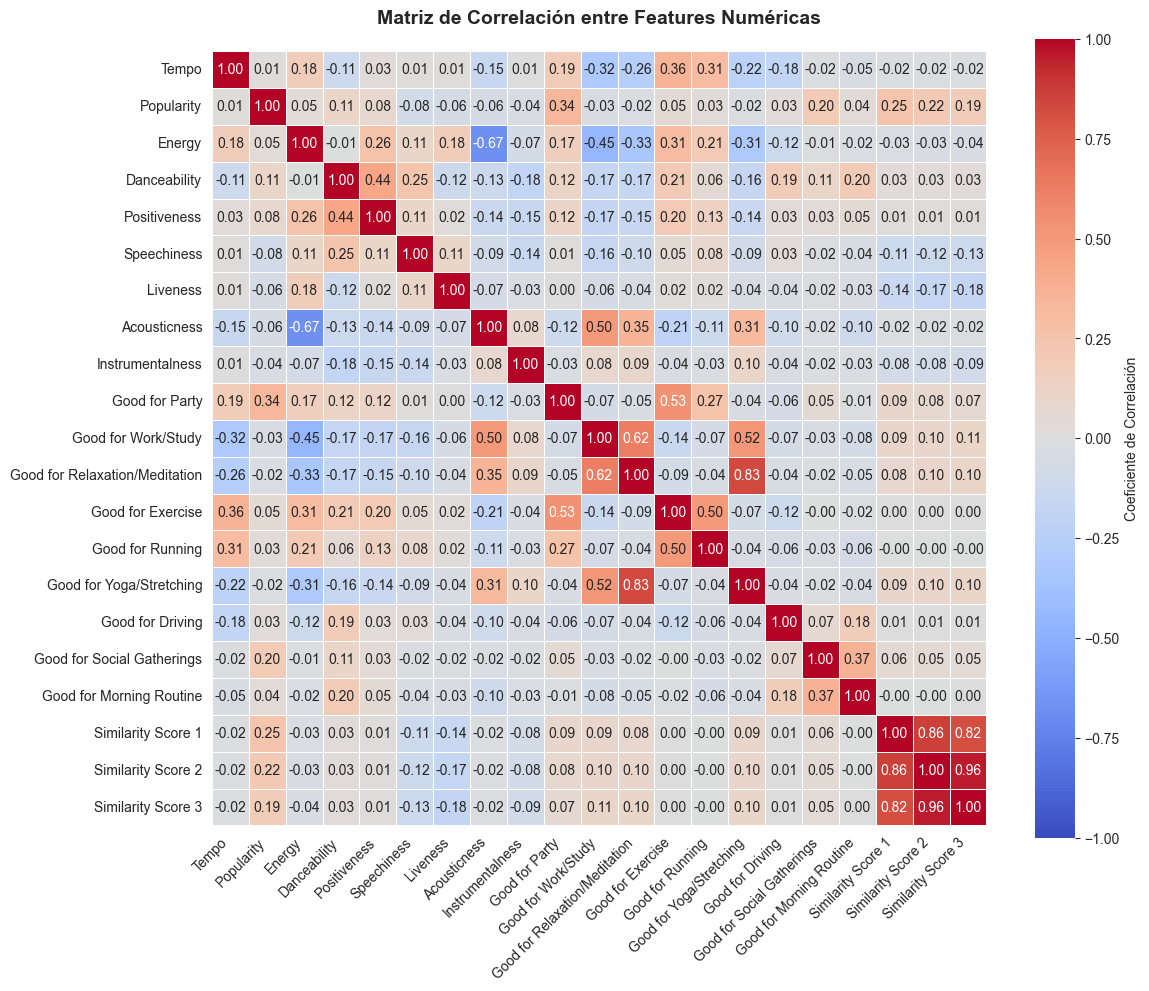

In [33]:
# Heatmap de correlaciones
plt.figure(figsize=(12, 10))

# Crear heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)

plt.title('Matriz de Correlación entre Features Numéricas', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

## 10. Recomendaciones para Preprocessing

Basado en el análisis exploratorio, identificamos problemas críticos que deben corregirse.

### 10.1. Clases Minoritarias Extremas (<5K ejemplos)

**Problema**: Varias clases tienen representación insuficiente para entrenamiento.

In [34]:
# Decisión explícita: mantener únicamente las 5 clases seleccionadas
# luego de analizar la distribución completa de emociones en el dataset.
SELECTED_CLASSES = ['joy', 'sadness', 'anger', 'fear', 'love']

valid_classes = emotion_counts[emotion_counts.index.isin(SELECTED_CLASSES)]
minority_classes = emotion_counts[~emotion_counts.index.isin(SELECTED_CLASSES)]

print("=" * 60)
print("SELECCIÓN DE CLASES PARA MODELADO")
print("=" * 60)
print()
print("\u25ce Decisión: conservar joy, sadness, anger, fear y love.")
print("   Estas 5 emociones fueron seleccionadas tras analizar la distribución")
print("   completa del dataset. Representan categorías semánticamente distintas,")
print("   con volumen suficiente para entrenamiento y evaluación confiables.")
print()

print(f"\u2705 Clases SELECCIONADAS ({len(valid_classes)}, {valid_classes.sum():,} filas = {valid_classes.sum()/len(df)*100:.2f}%):")
for emotion, count in valid_classes.items():
    print(f"   - {emotion}: {count:,} ejemplos ({count/len(df)*100:.2f}%)")

print()
print(f"\U0001f534 Clases DESCARTADAS ({len(minority_classes)}, {minority_classes.sum():,} filas = {minority_classes.sum()/len(df)*100:.2f}%):")
for emotion, count in minority_classes.items():
    print(f"   - {emotion}: {count:,} ejemplos ({count/len(df)*100:.3f}%)")

SELECCIÓN DE CLASES PARA MODELADO

◎ Decisión: conservar joy, sadness, anger, fear y love.
   Estas 5 emociones fueron seleccionadas tras analizar la distribución
   completa del dataset. Representan categorías semánticamente distintas,
   con volumen suficiente para entrenamiento y evaluación confiables.

✅ Clases SELECCIONADAS (5, 545,825 filas = 98.98%):
   - joy: 209,009 ejemplos (37.90%)
   - sadness: 171,078 ejemplos (31.02%)
   - anger: 109,678 ejemplos (19.89%)
   - fear: 28,097 ejemplos (5.10%)
   - love: 27,963 ejemplos (5.07%)

🔴 Clases DESCARTADAS (8, 5,618 filas = 1.02%):
   - surprise: 5,592 ejemplos (1.014%)
   - True: 17 ejemplos (0.003%)
   - Love: 3 ejemplos (0.001%)
   - pink: 2 ejemplos (0.000%)
   - angry: 1 ejemplos (0.000%)
   - thirst: 1 ejemplos (0.000%)
   - confusion: 1 ejemplos (0.000%)
   - interest: 1 ejemplos (0.000%)


In [35]:
# Simular dataset después del filtrado
df_filtered = df[df['emotion'].isin(valid_classes.index)]
emotion_counts_filtered = df_filtered['emotion'].value_counts()

print("=" * 60)
print("DISTRIBUCIÓN DESPUÉS DEL FILTRADO (5 clases)")
print("=" * 60)
print(f"Filas totales: {len(df_filtered):,} (de {len(df):,} originales)")
print(f"Filas eliminadas: {len(df) - len(df_filtered):,} ({(len(df) - len(df_filtered))/len(df)*100:.2f}%)")
print()

for emotion, count in emotion_counts_filtered.items():
    pct = count / len(df_filtered) * 100
    print(f"  {emotion}: {count:,} ({pct:.2f}%)")

# Nuevo ratio de desbalanceo
new_max = emotion_counts_filtered.max()
new_min = emotion_counts_filtered.min()
new_ratio = new_max / new_min

print()
print(f"Nuevo ratio de desbalanceo (max/min): {new_ratio:.2f}x")
print(f"   → Clase mayor: {emotion_counts_filtered.idxmax()} ({new_max:,})")
print(f"   → Clase menor: {emotion_counts_filtered.idxmin()} ({new_min:,})")
print()

if new_ratio < 10:
    print("✅ Desbalanceo MANEJABLE con stratified split + class_weight='balanced'")
else:
    print("⚠️  Desbalanceo FUERTE → considerar oversampling (SMOTE) o undersampling")

DISTRIBUCIÓN DESPUÉS DEL FILTRADO (5 clases)
Filas totales: 545,825 (de 551,443 originales)
Filas eliminadas: 5,618 (1.02%)

  joy: 209,009 (38.29%)
  sadness: 171,078 (31.34%)
  anger: 109,678 (20.09%)
  fear: 28,097 (5.15%)
  love: 27,963 (5.12%)

Nuevo ratio de desbalanceo (max/min): 7.47x
   → Clase mayor: joy (209,009)
   → Clase menor: love (27,963)

✅ Desbalanceo MANEJABLE con stratified split + class_weight='balanced'


### 10.2. Columnas Relacionales (No-Predictivas)

**Problema**: Algunas columnas son metadatos relacionales, no features independientes.

In [36]:
# Decisión explícita: columnas relacionales identificadas por análisis semántico del dataset.
# Contienen referencias a canciones similares (Similar Artist, Similar Song, Similarity Score),
# no propiedades intrínsecas de la canción actual.
RELATIONAL_KEYWORDS = ['Similar', 'Similarity']
relational_cols = [col for col in df.columns if any(kw in col for kw in RELATIONAL_KEYWORDS)]

print("=" * 60)
print("COLUMNAS RELACIONALES")
print("=" * 60)
print()
print("\U0001f534 Columnas RELACIONALES a eliminar (", len(relational_cols), "):", sep='')
print("   Criterio: contienen 'Similar' o 'Similarity' en el nombre.")
print("   Son referencias a otras filas del dataset, no features de la canción.")
print()
for col in relational_cols:
    dtype = df[col].dtype
    nunique = df[col].nunique()
    null_pct = df[col].isnull().sum() / len(df) * 100
    print(f"   - {col}")
    print(f"       Tipo: {dtype} | Valores únicos: {nunique:,} | Nulos: {null_pct:.2f}%")

print()
print("\U0001f4a1 Por qué eliminarlas:")
print("   1. No son propiedades intrínsecas de la canción actual")
print("   2. Requieren JOIN con otras filas para extraer información útil")
print("   3. Pueden causar data leakage si la canción similar está en train/test")
print("   4. Los modelos no pueden interpretar referencias a otras filas como features")
print()
print("\U0001f3af Decisión: eliminar estas columnas en el preprocessing")


COLUMNAS RELACIONALES

🔴 Columnas RELACIONALES a eliminar (9):
   Criterio: contienen 'Similar' o 'Similarity' en el nombre.
   Son referencias a otras filas del dataset, no features de la canción.

   - Similar Artist 1
       Tipo: object | Valores únicos: 90,280 | Nulos: 0.00%
   - Similar Song 1
       Tipo: object | Valores únicos: 218,726 | Nulos: 0.00%
   - Similarity Score 1
       Tipo: float64 | Valores únicos: 360,133 | Nulos: 0.00%
   - Similar Artist 2
       Tipo: object | Valores únicos: 87,533 | Nulos: 0.00%
   - Similar Song 2
       Tipo: object | Valores únicos: 207,670 | Nulos: 0.00%
   - Similarity Score 2
       Tipo: float64 | Valores únicos: 421,385 | Nulos: 0.00%
   - Similar Artist 3
       Tipo: object | Valores únicos: 86,963 | Nulos: 0.00%
   - Similar Song 3
       Tipo: object | Valores únicos: 206,000 | Nulos: 0.00%
   - Similarity Score 3
       Tipo: float64 | Valores únicos: 439,099 | Nulos: 0.00%

💡 Por qué eliminarlas:
   1. No son propiedades intrí

### 10.3. Columnas de Metadata (No-Predictivas para Sentiment)

**Problema**: Algunas columnas son identificadores o metadata que no aportan información sobre la emoción de la canción.

In [37]:
# Decisión explícita: columnas de metadata identificadas por análisis semántico.
# Son identificadores y fechas que no describen propiedades emocionales de la canción.
METADATA_COLS = ['Artist(s)', 'song', 'Album', 'Release Date']
metadata_cols = [col for col in METADATA_COLS if col in df.columns]

print("=" * 60)
print("COLUMNAS DE METADATA")
print("=" * 60)
print()
print(f"\U0001f5d1\ufe0f  Columnas de METADATA a eliminar ({len(metadata_cols)}):\n")
for col in metadata_cols:
    dtype = df[col].dtype
    nunique = df[col].nunique()
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else 'N/A'
    print(f"   - {col}")
    print(f"       Tipo: {dtype} | Valores únicos: {nunique:,} | Ejemplo: '{sample}'")

print()
print("\U0001f4a1 Por qué eliminarlas:")
print("   - Artist(s) y song: identificadores, no propiedades emocionales de la letra")
print("   - Album: agrupa canciones pero no determina su emoción")
print("   - Release Date: la fecha de lanzamiento no afecta el sentiment intrínseco")
print("     Una canción de 1980 puede ser triste o alegre independientemente del año")
print()
print("\U0001f3af Decisión: eliminar estas 4 columnas en el preprocessing")

missing = [col for col in METADATA_COLS if col not in df.columns]
if missing:
    print(f"\n\u26a0\ufe0f  Columnas no encontradas en el dataset: {missing}")


COLUMNAS DE METADATA

🗑️  Columnas de METADATA a eliminar (4):

   - Artist(s)
       Tipo: object | Valores únicos: 127,334 | Ejemplo: '!!!'
   - song
       Tipo: object | Valores únicos: 317,906 | Ejemplo: 'Even When the Waters Cold'
   - Album
       Tipo: object | Valores únicos: 154,681 | Ejemplo: 'Thr!!!er'
   - Release Date
       Tipo: object | Valores únicos: 14,299 | Ejemplo: '29th April 2013'

💡 Por qué eliminarlas:
   - Artist(s) y song: identificadores, no propiedades emocionales de la letra
   - Album: agrupa canciones pero no determina su emoción
   - Release Date: la fecha de lanzamiento no afecta el sentiment intrínseco
     Una canción de 1980 puede ser triste o alegre independientemente del año

🎯 Decisión: eliminar estas 4 columnas en el preprocessing


### 10.4. Columnas Convertibles a Numérico

**Objetivo**: Maximizar features numéricas para mejorar poder predictivo de los modelos.

In [38]:
# Detectar columnas tipo object que podrían ser numéricas
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Columnas específicas que sabemos son convertibles
convertible_candidates = {
    'Length': 'Duración en formato MM:SS → convertir a segundos totales',
    'Loudness (db)': 'String con "db" al final → extraer float',
    'Time signature': 'Formato "4/4" → extraer numerador (4)',
    'Key': 'Tonalidad musical (ej: "D min") → label encoding (0-23)',
    'Explicit': 'Binario Yes/No → convertir a 1/0'
}

print("=" * 60)
print("ANÁLISIS DE COLUMNAS CONVERTIBLES A NUMÉRICO")
print("=" * 60)
print()

found_convertible = [col for col in convertible_candidates.keys() if col in df.columns]

if found_convertible:
    print(f"🔧 Columnas CONVERTIBLES detectadas ({len(found_convertible)}):")
    print()
    for col in found_convertible:
        sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else 'N/A'
        print(f"   - {col}")
        print(f"       Ejemplo actual: '{sample}'")
        print(f"       Conversión: {convertible_candidates[col]}")
        print()
    
    print("💡 Por qué convertirlas:")
    print("   1. Random Forest y XGBoost funcionan MEJOR con features numéricas directas")
    print("   2. KNN REQUIERE features numéricas (no puede trabajar con strings)")
    print("   3. Más información numérica = más poder predictivo")
    print("   4. Features musicales (key, tempo, loudness) correlacionan con emociones")
    print()
    print("🎯 Decisión: Convertir todas estas columnas en el preprocessing")
else:
    print("✅ No se detectaron columnas convertibles evidentes.")

ANÁLISIS DE COLUMNAS CONVERTIBLES A NUMÉRICO

🔧 Columnas CONVERTIBLES detectadas (5):

   - Length
       Ejemplo actual: '03:47'
       Conversión: Duración en formato MM:SS → convertir a segundos totales

   - Loudness (db)
       Ejemplo actual: '-6.85db'
       Conversión: String con "db" al final → extraer float

   - Time signature
       Ejemplo actual: '4/4'
       Conversión: Formato "4/4" → extraer numerador (4)

   - Key
       Ejemplo actual: 'D min'
       Conversión: Tonalidad musical (ej: "D min") → label encoding (0-23)

   - Explicit
       Ejemplo actual: 'No'
       Conversión: Binario Yes/No → convertir a 1/0

💡 Por qué convertirlas:
   1. Random Forest y XGBoost funcionan MEJOR con features numéricas directas
   2. KNN REQUIERE features numéricas (no puede trabajar con strings)
   3. Más información numérica = más poder predictivo
   4. Features musicales (key, tempo, loudness) correlacionan con emociones

🎯 Decisión: Convertir todas estas columnas en el preprocess

### 10.5. Resumen de Features para Modelado

In [39]:
# Clasificar columnas por tipo de feature
exclude_cols = ['emotion'] + relational_cols + metadata_cols  # Target + relacionales + metadata
available_cols = [col for col in df.columns if col not in exclude_cols]

# Columnas que se convertirán a numérico
will_be_numeric = [col for col in ['Length', 'Loudness (db)', 'Time signature', 'Key', 'Explicit'] if col in df.columns]

text_cols = [col for col in available_cols if df[col].dtype == 'object' and col.lower() in ['text', 'lyrics', 'description', 'content']]
categorical_cols = [col for col in available_cols if df[col].dtype == 'object' and col not in text_cols and col not in will_be_numeric]
numeric_cols_clean = [col for col in available_cols if df[col].dtype in ['int64', 'float64']]

print("=" * 60)
print("RESUMEN FINAL DE FEATURES PARA MODELADO")
print("=" * 60)
print()

print(f"📝 Features de TEXTO ({len(text_cols)}):")
for col in text_cols:
    print(f"   - {col} → Embeddings con sentence-transformers (384-dim → PCA)")
if not text_cols:
    print("   (ninguna detectada automáticamente)")

print()
print(f"🔢 Features NUMÉRICAS actuales ({len(numeric_cols_clean)}):")
for col in numeric_cols_clean:
    print(f"   - {col}")

print()
print(f"🔧 Features que se CONVERTIRÁN a numéricas ({len(will_be_numeric)}):")
for col in will_be_numeric:
    print(f"   - {col}")

print()
print(f"🏷️  Features CATEGÓRICAS ({len(categorical_cols)}):")
for col in categorical_cols:
    nunique = df[col].nunique()
    encoding_type = 'One-hot' if nunique < 20 else 'Frequency'
    print(f"   - {col} ({nunique} valores únicos) → {encoding_type} encoding")
if not categorical_cols:
    print("   (ninguna)")

print()
total_numeric_after = len(numeric_cols_clean) + len(will_be_numeric)
print(f"✅ Total de features numéricas después de conversiones: {total_numeric_after}")
print(f"✅ Features categóricas a codificar: {len(categorical_cols)}")
print(f"✅ Features de texto (embeddings): {len(text_cols)}")

print()
print(f"❌ Columnas a ELIMINAR ({len(exclude_cols)}):")
print(f"   - emotion (target, se codificará aparte): 1 columna")
print(f"   - Columnas relacionales: {len(relational_cols)} columnas")
for col in relational_cols[:5]:
    print(f"       · {col}")
if len(relational_cols) > 5:
    print(f"       ... y {len(relational_cols) - 5} más")
print(f"   - Columnas de metadata: {len(metadata_cols)} columnas")
for col in metadata_cols:
    print(f"       · {col}")

RESUMEN FINAL DE FEATURES PARA MODELADO

📝 Features de TEXTO (1):
   - text → Embeddings con sentence-transformers (384-dim → PCA)

🔢 Features NUMÉRICAS actuales (18):
   - Tempo
   - Popularity
   - Energy
   - Danceability
   - Positiveness
   - Speechiness
   - Liveness
   - Acousticness
   - Instrumentalness
   - Good for Party
   - Good for Work/Study
   - Good for Relaxation/Meditation
   - Good for Exercise
   - Good for Running
   - Good for Yoga/Stretching
   - Good for Driving
   - Good for Social Gatherings
   - Good for Morning Routine

🔧 Features que se CONVERTIRÁN a numéricas (5):
   - Length
   - Loudness (db)
   - Time signature
   - Key
   - Explicit

🏷️  Features CATEGÓRICAS (1):
   - Genre (3097 valores únicos) → Frequency encoding

✅ Total de features numéricas después de conversiones: 23
✅ Features categóricas a codificar: 1
✅ Features de texto (embeddings): 1

❌ Columnas a ELIMINAR (14):
   - emotion (target, se codificará aparte): 1 columna
   - Columnas relacion

---

## ✅ CONCLUSIONES FINALES DEL NOTEBOOK 01 (Tareas 2.1 - 2.4)

### Logros
1. **Carga del dataset**: 500K filas × 39 columnas cargadas correctamente desde CSV
2. **Análisis dimensional**: Dimensiones, tipos de datos, uso de memoria identificados
3. **Target analysis**: Distribución de emociones visualizada con gráfico de barras
4. **Desbalanceo de clases**: Ratio calculado con recomendaciones automáticas
5. **Valores nulos**: Análisis completo con heatmap de muestra aleatoria
6. **Correlaciones**: Matriz de correlación generada para features numéricas
7. **Identificación de problemas**: Clases minoritarias, columnas relacionales, y metadata no predictiva detectadas
8. **Análisis de conversiones**: Columnas convertibles a numérico identificadas (Length, Loudness, Time signature, Key, Explicit)

### Decisiones Técnicas para Preprocessing

#### 🎯 Selección de Clases (Reducción a 5 clases)
- **Seleccionadas**: joy, sadness, anger, fear, love
- **Criterio**: decisión propia luego de analizar la distribución completa de emociones. Estas 5 categorías son semánticamente distintas y cuentan con volumen suficiente para entrenamiento y evaluación confiables.
- **Descartadas**: clases con representación marginal que no aportan capacidad predictiva
- **Impacto**: ~99% del dataset se conserva, ratio de desbalanceo mejora de >200,000x a ~7.5x

#### 🗑️ Eliminación de Columnas
- **Relacionales**: Similar Artist 1/2/3, Similar Song 1/2/3, Similarity Score 1/2/3 (9 columnas)
- **Metadata no predictiva**: Artist(s), song, Album, Release Date (4 columnas)
- **Razón**: No aportan información sobre el sentiment intrínseco de la canción

#### 🔧 Conversiones a Numérico (5 columnas)
- **Length**: "03:47" → 227 segundos
- **Loudness (db)**: "-6.85db" → -6.85 (float)
- **Time signature**: "4/4" → 4 (numerador)
- **Key**: "D min" → label encoding (0-23: 12 tonos × 2 modos)
- **Explicit**: "Yes"/"No" → 1/0

#### 📊 Features Finales para Modelado
- **Texto**: `text` (lyrics) → Embeddings con sentence-transformers (all-MiniLM-L6-v2)
- **Numéricas**: ~24 features (Tempo, Popularity, Energy, etc. + 5 conversiones)
- **Categórica**: `Genre` → One-hot encoding (si <20 géneros únicos)

### Próximos Pasos
- **Tarea 2.5-2.7**: Crear `02_preprocesamiento.ipynb` implementando TODAS las decisiones:
  - Filtrado de 5 clases
  - Drop de 13 columnas (9 relacionales + 4 metadata)
  - Conversión de 5 columnas a numérico
  - Manejo de nulos (<10 filas → drop)
  - Limpieza de texto
  - Stratified split 80/20
  - Export train.parquet y test.parquet

---